# Regression Tree (Manual Implementation)

Implementasi manual Regression Tree menggunakan **SSR (Sum of Squared Residuals)** sebagai kriteria split.  
Dilengkapi dengan evaluasi **MSE, RMSE, R-Squared** dan **Depth Tuning Analysis**.

---

## 1. Import Library

In [1]:
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Library untuk evaluasi metrik dan tracking
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")


Library berhasil di-import!


---
## 2. Struktur Node

- Jika node adalah **percabangan (decision)**: hanya terisi `feature_index`, `threshold`, `left`, `right`
- Jika node adalah **leaf**: `value` berisi rata-rata target
- `is_leaf()` untuk mengecek apakah node adalah leaf

In [2]:
# Sama seperti classification tree
# Jika node adalah percabangan (decision), terisi 4 var pertama
# Jika node adalah leaf, value berisi rata-rata target
# is_leaf untuk ngecek isi value
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

print("Class Node berhasil didefinisikan.")

Class Node berhasil didefinisikan.


---
## 3. Class RegressionTreeRegressor

Implementasi regression tree dengan **SSR (Sum of Squared Residuals)**.

**Hyperparameter:**
- `max_depth`: kedalaman maksimum tree
- `min_samples_split`: jumlah minimum data pada node agar bisa dipecah

**Tambahan:**


In [3]:
class RegressionTreeRegressor:
    # Hyperparameter
    # max_depth: kedalaman maksimum tree
    # min_samples_split: jumlah minimum data pada node agar bisa dipecah lagi
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # ENTRY POINT
    # Mapping feature dan target value (continuous)
    def fit(self, X, y):
        data = [row + [label] for row, label in zip(X, y)]
        self.root = self.build_tree(data, depth=0)

    # Predict sebanyak jumlah data yang ada
    def predict(self, X):
        return [self.predict_one(row, self.root) for row in X]

    # Selama bukan leaf, ke node lain
    def predict_one(self, row, node):
        while not node.is_leaf():
            if row[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    # Membuat tree
    # 1. cek status (apakah sudah di ujung / leaf)
    # 2. cari strategi best split data
    # 3. potong data, buat branch baru
    # 4. construct tree
    def build_tree(self, data, depth):
        # Mengambil y saja
        y = [row[-1] for row in data]

        num_samples = len(y)

        # Base condition: sudah melebihi depth max
        #                 semua nilai y identik (SSR = 0)
        #                 mencapai min sample split
        # Return: node dengan nilai rata-rata y
        # LEAF
        if (
            depth >= self.max_depth
            or len(set(y)) == 1
            or num_samples < self.min_samples_split
        ):
            return Node(value=self.mean(y))

        # Mencari split data terbaik
        best_feature, best_threshold, best_gain = self.best_split(data)

        # Jika split tidak mengurangi SSR sama sekali, buat leaf
        if best_gain == 0:
            return Node(value=self.mean(y))

        # Lakukan split data ke branch kiri dan kanan
        left_data, right_data = self.split(data, best_feature, best_threshold)

        # Membuat branch baru
        left_child = self.build_tree(left_data, depth + 1)
        right_child = self.build_tree(right_data, depth + 1)

        # Membuat node baru
        return Node(best_feature, best_threshold, left_child, right_child)

    # Split function, brute force untuk dapat split terbaik
    def best_split(self, data):
        best_gain = -1
        best_feature = None
        best_threshold = None

        # Menghitung SSR berdasarkan semua fitur yang ada
        n_features = len(data[0]) - 1
        current_ssr = self.ssr([row[-1] for row in data])

        # Mengambil unique data untuk dilakukan perhitungan SSR
        # threshold dihitung dengan mengambil range tengah (midpoint)
        for feature_index in range(n_features):
            values = sorted(set(row[feature_index] for row in data))
            # jika hanya 1 nilai (tidak ada range)
            # tidak perlu dihitung mid point, ke iterasi berikut
            if len(values) == 1:
                continue

            # Mencari mid point dari setiap 2 titik
            thresholds = [(values[i] + values[i + 1]) / 2 for i in range(len(values) - 1)]

            # Iterasi split untuk semua titik mid point
            for threshold in thresholds:
                left_data, right_data = self.split(data, feature_index, threshold)
                # Jika salah satu sisi kosong, lanjut iterasi berikutnya
                if not left_data or not right_data:
                    continue

                # Ambil label dari sisi kiri dan kanan
                # lalu hitung gain berdasarkan pengurangan SSR parent
                left_y = [row[-1] for row in left_data]
                right_y = [row[-1] for row in right_data]
                gain = self.ssr_gain(current_ssr, left_y, right_y)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold

        if best_gain < 0:
            best_gain = 0

        return best_feature, best_threshold, best_gain

    # Membagi data berdasarkan index dan threshold yang ditentukan
    def split(self, data, feature_index, threshold):
        left = [row for row in data if row[feature_index] <= threshold]
        right = [row for row in data if row[feature_index] > threshold]
        return left, right

    # Menghitung SSR (Sum of Squared Residuals)
    # Mengukur seberapa jauh nilai y dari rata-ratanya dalam suatu node
    # SSR = 0 berarti semua nilai y identik (murni)
    # Makin besar SSR, makin bervariasi nilainya
    # SSR = sum((y_i - mean(y))^2)
    def ssr(self, labels):
        if len(labels) == 0:
            return 0
        m = self.mean(labels)
        return sum((val - m) ** 2 for val in labels)

    # Menghitung gain (seberapa besar SSR berkurang setelah split)
    # Gain = SSR parent - (SSR kiri + SSR kanan)
    # Berbeda dari classification: SSR tidak di-weight karena sudah absolut
    def ssr_gain(self, parent_ssr, left_y, right_y):
        child_ssr = self.ssr(left_y) + self.ssr(right_y)
        return parent_ssr - child_ssr

    # Return rata-rata label dalam node
    # Digunakan sebagai prediksi pada leaf node
    def mean(self, labels):
        return sum(labels) / len(labels)

print("Class RegressionTreeRegressor berhasil didefinisikan.")

Class RegressionTreeRegressor berhasil didefinisikan.


---
## 4. Fungsi Visualisasi Tree

In [4]:
def plot_tree(node, feature_names, x=0, y=0, dx=2.5, depth=0, ax=None):
    # Buat canvas
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.axis("off")

    # Jika leaf, print nilai rata-rata prediksi
    # Jika bukan leaf, print feature dan threshold
    if node.is_leaf():
        text = f"Val: {node.value:.4f}"
    else:
        feature = feature_names[node.feature_index]
        text = f"{feature} <= {node.threshold:.2f}"

    # Menggambar box text
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round", facecolor="lightyellow")
    )

    # Menggambar layered tree
    if not node.is_leaf():
        left_x = x - dx / (depth + 1)
        right_x = x + dx / (depth + 1)
        child_y = y - 1.5

        # Menentukan warna dan jenis line penghubung
        ax.plot([x, left_x], [y, child_y], "k-")
        ax.plot([x, right_x], [y, child_y], "k-")

        # Visualisasi tree, ambil dari class node
        plot_tree(node.left, feature_names, left_x, child_y, dx, depth + 1, ax)
        plot_tree(node.right, feature_names, right_x, child_y, dx, depth + 1, ax)

    return ax

print("Fungsi plot_tree berhasil didefinisikan.")

Fungsi plot_tree berhasil didefinisikan.


---
## 5. Fungsi Evaluasi Metrik

Menghitung **MSE, RMSE, R-Squared** menggunakan sklearn dan menampilkan **Scatter Plot Actual vs Predicted**.

In [5]:
def evaluate_model(y_true, y_pred, title="Evaluation"):
    """
    Menghitung dan menampilkan metrik evaluasi regresi:
    - MSE (Mean Squared Error)
    - RMSE (Root Mean Squared Error)
    - R-Squared (Coefficient of Determination)
    - Scatter Plot Actual vs Predicted
    - Residual Plot
    """
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n  MSE       : {mse:.6f}")
    print(f"  RMSE      : {rmse:.6f}")
    print(f"  R-Squared : {r2:.6f}  ({r2*100:.2f}%)")
    
    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.5, color='steelblue', edgecolors='k', linewidth=0.5, s=30)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (y=x)')
    axes[0].set_xlabel('Actual (redshift)', fontsize=12)
    axes[0].set_ylabel('Predicted (redshift)', fontsize=12)
    axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Residual Plot
    residuals = [a - p for a, p in zip(y_true, y_pred)]
    axes[1].scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='k', linewidth=0.5, s=30)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted (redshift)', fontsize=12)
    axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
    axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return {'mse': mse, 'rmse': rmse, 'r2': r2}

print("Fungsi evaluate_model berhasil didefinisikan.")

Fungsi evaluate_model berhasil didefinisikan.


---
## 6. Fungsi Depth Tuning Analysis

Melakukan training dengan berbagai `max_depth` dan membandingkan performa untuk menentukan depth optimal.

In [6]:
def depth_tuning_analysis(X_train, y_train, X_test, y_test, max_depth_range=range(1, 11)):
    """
    Analisis performa model pada berbagai max_depth.
    Menampilkan grafik MSE, RMSE, R-Squared vs max_depth.
    """
    results = []
    
    for depth in max_depth_range:
        reg = RegressionTreeRegressor(max_depth=depth)
        reg.fit(X_train, y_train)
        
        # Evaluasi train
        y_pred_train = reg.predict(X_train)
        mse_train = mean_squared_error(y_train, y_pred_train)
        
        # Evaluasi test
        y_pred_test = reg.predict(X_test)
        mse_test = mean_squared_error(y_test, y_pred_test)
        rmse_test = np.sqrt(mse_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        results.append({
            'max_depth': depth,
            'train_mse': round(mse_train, 6),
            'test_mse': round(mse_test, 6),
            'test_rmse': round(rmse_test, 6),
            'test_r2': round(r2_test, 6)
        })
    
    df_results = pd.DataFrame(results)
    print("\n--- Depth Tuning Results ---")
    print(df_results.to_string(index=False))
    
    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Train vs Test MSE
    axes[0].plot(df_results['max_depth'], df_results['train_mse'], 'o-', 
                label='Train MSE', color='blue', linewidth=2)
    axes[0].plot(df_results['max_depth'], df_results['test_mse'], 's-', 
                label='Test MSE', color='red', linewidth=2)
    axes[0].set_xlabel('Max Depth')
    axes[0].set_ylabel('MSE')
    axes[0].set_title('Train vs Test MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Test R-Squared
    axes[1].plot(df_results['max_depth'], df_results['test_r2'], 'D-', 
                label='R-Squared', color='green', linewidth=2, markersize=8)
    axes[1].set_xlabel('Max Depth')
    axes[1].set_ylabel('R-Squared')
    axes[1].set_title('Test R-Squared per Depth')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Best depth
    best_idx = df_results['test_r2'].idxmax()
    best_depth = df_results.loc[best_idx, 'max_depth']
    print(f"\n>> Best max_depth berdasarkan R-Squared (test): {best_depth}")
    
    return df_results

print("Fungsi depth_tuning_analysis berhasil didefinisikan.")

Fungsi depth_tuning_analysis berhasil didefinisikan.


---
---
# START 1: Dataset Makro

Dataset makro menggunakan **sdss_100k_galaxy_form_burst.csv** dengan **35 fitur** dan target **redshift** (continuous).

---

### 8a. Load Dataset Makro

In [7]:
# Baca dataset CSV makro
df_makro = pd.read_csv("DataReg.csv")

print(f"Shape dataset: {df_makro.shape}")
print(f"Kolom: {list(df_makro.columns)}")
print(f"\nStatistik target (redshift):")
print(df_makro['redshift'].describe())
print(f"\n{df_makro.head()}")

Shape dataset: (10000, 37)
Kolom: ['u', 'g', 'r', 'i', 'z', 'modelFlux_u', 'modelFlux_g', 'modelFlux_r', 'modelFlux_i', 'modelFlux_z', 'petroRad_u', 'petroRad_g', 'petroRad_i', 'petroRad_r', 'petroRad_z', 'petroFlux_u', 'petroFlux_g', 'petroFlux_i', 'petroFlux_r', 'petroFlux_z', 'petroR50_u', 'petroR50_g', 'petroR50_i', 'petroR50_r', 'petroR50_z', 'psfMag_u', 'psfMag_r', 'psfMag_g', 'psfMag_i', 'psfMag_z', 'expAB_u', 'expAB_g', 'expAB_r', 'expAB_i', 'expAB_z', 'redshift', 'redshift_err']

Statistik target (redshift):
count    10000.000000
mean         0.112615
std          0.093877
min         -0.000619
25%          0.055765
50%          0.084804
75%          0.132422
max          0.561523
Name: redshift, dtype: float64

          u         g         r         i         z  modelFlux_u  modelFlux_g  \
0  19.53920  18.49463  17.80479  17.44611  17.24578    15.285630     40.00774   
1  20.04008  18.63083  17.94050  17.52629  17.24970     9.635576     35.29115   
2  18.88969  17.45173  16.

### 8b. Persiapan Data Makro (Train-Test Split)

In [8]:
# Feature dan target
feature_names_makro = [
    'modelFlux_g', 'psfMag_z', 'psfMag_g', 'petroFlux_g', 'modelFlux_u'
]

df_makro_limited = df_makro.sample(n=10000, random_state=37)

X_makro = df_makro[feature_names_makro].values.tolist()
y_makro = df_makro["redshift"].tolist()

# Train-test split (80% train, 20% test)
X_train_makro, X_test_makro, y_train_makro, y_test_makro = train_test_split(
    X_makro, y_makro, test_size=0.2, random_state=42
)

print(f"Total data    : {len(X_makro)}")
print(f"Training data : {len(X_train_makro)}")
print(f"Testing data  : {len(X_test_makro)}")
print(f"Jumlah fitur  : {len(feature_names_makro)}")

Total data    : 10000
Training data : 8000
Testing data  : 2000
Jumlah fitur  : 5


### 8c. Training Model - Makro

In [9]:
# Training Regression Tree - Dataset Makro
reg_makro = RegressionTreeRegressor(max_depth=5)
reg_makro.fit(X_train_makro, y_train_makro)

print("Training selesai!")
print(f"Max depth (set): {reg_makro.max_depth}")

Training selesai!
Max depth (set): 5


### 8e. Prediksi & Evaluasi - Makro


  Dataset Makro (5 Fitur)

  MSE       : 0.003104
  RMSE      : 0.055715
  R-Squared : 0.662996  (66.30%)


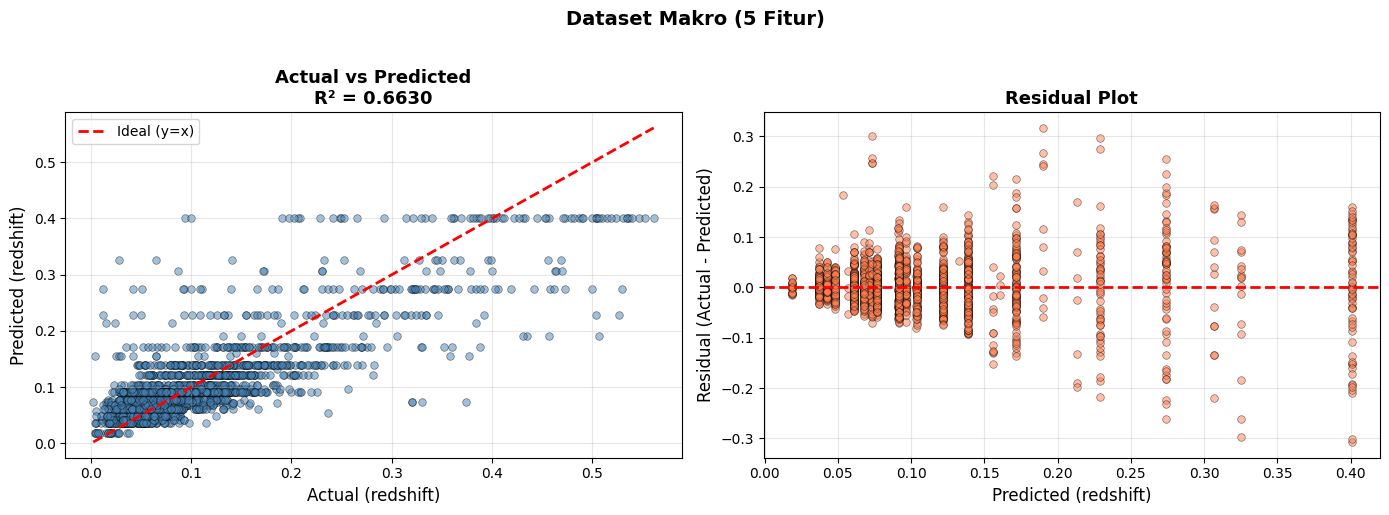

In [11]:
# Prediksi pada data test
y_pred_makro = reg_makro.predict(X_test_makro)

# Evaluasi metrik
metrics_makro = evaluate_model(y_test_makro, y_pred_makro, title="Dataset Makro (5 Fitur)")

### 8f. Visualisasi Tree - Makro

In [ ]:
# Visualisasi tree
plt.rc('font', size=8)
plot_tree(reg_makro.root, feature_names_makro)
plt.title("Regression Tree (SSR) - Dataset Makro", fontsize=14, fontweight='bold')
plt.show()

### 8g. Depth Tuning - Makro

In [ ]:
# Analisis depth tuning
df_tuning_makro = depth_tuning_analysis(
    X_train_makro, y_train_makro, 
    X_test_makro, y_test_makro, 
    max_depth_range=range(1, 11)
)

---
---
# START 2: Dataset Mikro (Tracing)

Dataset mikro menggunakan **dataMikro.csv** dengan fitur **u, g, r** (X) dan target **redshift** (y).  
Semua data digunakan untuk training (**tanpa split**). Tujuan utama adalah untuk **tracing** proses regression tree.

---

### 9a. Load Dataset Mikro

In [9]:
# Baca dataset CSV mikro
df_mikro = pd.read_csv("dataMikro.csv")

print(f"Shape dataset: {df_mikro.shape}")
print(f"Kolom: {list(df_mikro.columns)}")
print(f"\nStatistik target (redshift):")
print(df_mikro['redshift'].describe())
print(f"\n{df_mikro}")

Shape dataset: (10, 6)
Kolom: ['ID', 'u', 'g', 'r', 'subclass', 'redshift']

Statistik target (redshift):
count    10.000000
mean      0.138000
std       0.064944
min       0.080000
25%       0.092500
50%       0.110000
75%       0.195000
max       0.240000
Name: redshift, dtype: float64

   ID     u     g     r     subclass  redshift
0   1  18.5  17.2  16.6  STARFORMING      0.08
1   2  19.8  18.4  17.4  STARFORMING      0.11
2   3  21.7  20.2  19.3    STARBURST      0.23
3   4  20.6  19.3  18.6  STARFORMING      0.10
4   5  23.6  21.1  19.9    STARBURST      0.24
5   6  19.4  18.1  17.5  STARFORMING      0.11
6   7  20.2  18.6  17.7  STARFORMING      0.12
7   8  18.4  17.2  16.6    STARBURST      0.09
8   9  18.7  17.5  17.0  STARFORMING      0.08
9  10  19.8  18.4  17.4    STARBURST      0.22


### 9b. Persiapan Data Mikro

Semua data digunakan untuk training (tanpa split). Tujuan dataset mikro adalah untuk **tracing** proses regression tree.

In [10]:
# Feature: u, g, r | Target: redshift
feature_names_mikro = ['u', 'g', 'r']

X_mikro = df_mikro[feature_names_mikro].values.tolist()
y_mikro = df_mikro["redshift"].tolist()

# Semua data digunakan untuk training (untuk tracing)
print(f"Total data   : {len(X_mikro)}")
print(f"Jumlah fitur : {len(feature_names_mikro)}")
print(f"Fitur        : {feature_names_mikro}")
print(f"\nData X:")
for i, row in enumerate(X_mikro):
    print(f"  [{i+1}] u={row[0]}, g={row[1]}, r={row[2]}  ->  redshift={y_mikro[i]}")

Total data   : 10
Jumlah fitur : 3
Fitur        : ['u', 'g', 'r']

Data X:
  [1] u=18.5, g=17.2, r=16.6  ->  redshift=0.08
  [2] u=19.8, g=18.4, r=17.4  ->  redshift=0.11
  [3] u=21.7, g=20.2, r=19.3  ->  redshift=0.23
  [4] u=20.6, g=19.3, r=18.6  ->  redshift=0.1
  [5] u=23.6, g=21.1, r=19.9  ->  redshift=0.24
  [6] u=19.4, g=18.1, r=17.5  ->  redshift=0.11
  [7] u=20.2, g=18.6, r=17.7  ->  redshift=0.12
  [8] u=18.4, g=17.2, r=16.6  ->  redshift=0.09
  [9] u=18.7, g=17.5, r=17.0  ->  redshift=0.08
  [10] u=19.8, g=18.4, r=17.4  ->  redshift=0.22


### 9c. Training Model Mikro

In [15]:
# Training Regression Tree - Dataset Mikro (semua data)
reg_mikro = RegressionTreeRegressor(max_depth=2)
reg_mikro.fit(X_mikro, y_mikro)

print("Training selesai!")
print(f"Max depth (set): {reg_mikro.max_depth}")

Training selesai!
Max depth (set): 2


### 9e. Visualisasi Tree - Mikro

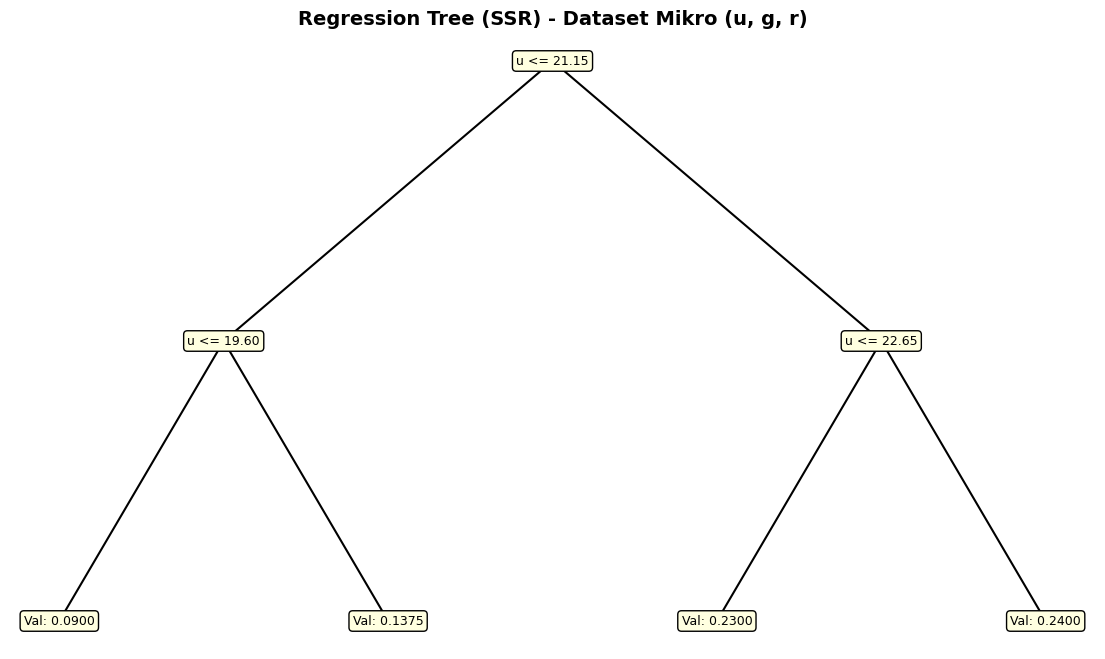

In [17]:
# Visualisasi tree
plt.rc('font', size=9)
plot_tree(reg_mikro.root, feature_names_mikro)
plt.title("Regression Tree (SSR) - Dataset Mikro (u, g, r)", fontsize=14, fontweight='bold')
plt.show()

### 9f. Prediksi Hardcoded (Tracing)

Melakukan prediksi dengan data hardcoded untuk **menelusuri (tracing)** jalur keputusan pada tree yang sudah dibangun.

In [ ]:
# Data prediksi hardcoded untuk tracing
# Format: [u, g, r]
test_mikro = [
    [19.5, 18.0, 17.2]
]

print("="*60)
print("  TRACING PREDIKSI - Dataset Mikro")
print("="*60)
print(f"\nInput data: u={test_mikro[0][0]}, g={test_mikro[0][1]}, r={test_mikro[0][2]}")
print(f"\n--- Tracing jalur keputusan ---")

# Tracing: telusuri tree dari root ke leaf
node = reg_mikro.root
step = 1
row = test_mikro[0]

while not node.is_leaf():
    feature_name = feature_names_mikro[node.feature_index]
    feature_value = row[node.feature_index]
    threshold = node.threshold
    
    if feature_value <= threshold:
        direction = "KIRI (<=)"
        node = node.left
    else:
        direction = "KANAN (>)"
        node = node.right
    
    print(f"  Step {step}: {feature_name} = {feature_value} vs threshold = {threshold:.4f}  ->  {direction}")
    step += 1

print(f"\n>> Hasil prediksi (redshift): {node.value:.6f}")

# Prediksi via method predict
pred_mikro = reg_mikro.predict(test_mikro)
print(f">> Verifikasi via predict(): {pred_mikro[0]:.6f}")